<a href="https://colab.research.google.com/github/camilapereira1304/TCC_UFRPE/blob/main/tcc_melhorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
#  1. INSTALAR BIBLIOTECAS
# =========================================
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 23.8 MB/s eta 0:00:00


In [ ]:
# =========================================
#  2. IMPORTAR BIBLIOTECAS
# =========================================
import numpy as np                  # operações numéricas
import pandas as pd                # manipulação de dados em tabela

from nilearn import datasets       # baixar datasets e atlas
from nilearn.input_data import NiftiLabelsMasker  # extrair sinais do cérebro
from nilearn.connectome import ConnectivityMeasure # calcular conectividade

from sklearn.model_selection import train_test_split, GridSearchCV # divisão e otimização
from sklearn.pipeline import Pipeline   # criar pipeline (organiza etapas)
from sklearn.preprocessing import StandardScaler # normalização
from sklearn.decomposition import PCA   # redução de dimensionalidade
from sklearn.svm import SVC             # modelo SVM
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

/tmp/ipykernel_6828/861163153.py:8: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker  # extrair sinais do cérebro


In [ ]:
# Baixar apenas dados do centro da NYU (Universidade de Nova York) para evitar efeito de sítio
abide = datasets.fetch_abide_pcp(
    pipeline='cpac',
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=['func_preproc'],
    SITE_ID=['NYU'] # Filtra apenas exames deste centro específico
)

[fetch_abide_pcp] Added README.md to /root/nilearn_data

[fetch_abide_pcp] Dataset created in /root/nilearn_data/ABIDE_pcp

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Phenotypic_V1_0b_preprocessed1.csv ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/func_preproc/NYU_005095
2_func_preproc.nii.gz ...

...

[fetch_abide_pcp]  ...done. (3 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/func_preproc/NYU_005115
9_func_preproc.nii.gz ...

[fetch_abide_pcp] Downloaded 44720128 of 103783342 bytes (43.1%%,    1.3s remaining)

[fetch_abide_pcp] Downloaded 90521600 of 103783342 bytes (87.2%%,    0.3s remaining)

[fetch_abide_pcp]  ...done. (3 seconds, 0 min)

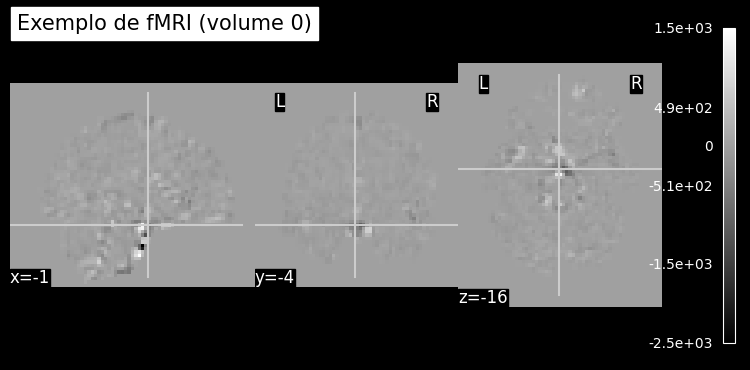

In [ ]:
#Visualizar cérebro
from nilearn import image, plotting

img_4d = image.load_img(abide.func_preproc[0])

# pega o primeiro volume (tempo = 0)
img_3d = image.index_img(img_4d, 0)

plotting.plot_epi(img_3d, title="Exemplo de fMRI (volume 0)")
plotting.show()

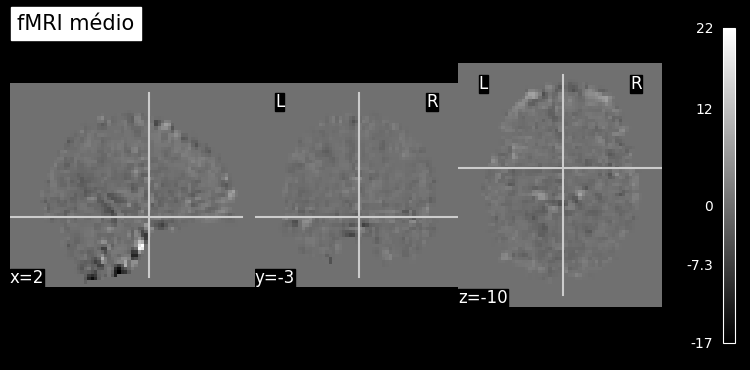

In [ ]:
from nilearn import image, plotting

img_4d = image.load_img(abide.func_preproc[0])

# média ao longo do tempo
mean_img = image.mean_img(img_4d)

plotting.plot_epi(mean_img, title="fMRI médio")
plotting.show()

In [ ]:
#Ver dimensão do fMRI
from nilearn import image

img = image.load_img(abide.func_preproc[0])
print("Dimensão da imagem:", img.shape)

Dimensão da imagem: (61, 73, 61, 176)


In [ ]:
# =========================================
#  4. DADOS FENOTÍPICOS (TABELA)
# =========================================
df = pd.DataFrame(abide.phenotypic)  # transforma em tabela

# cria rótulo: 1 = autismo | 0 = controle
df['label'] = df['DX_GROUP'].apply(lambda x: 1 if x == 1 else 0)

# QUANTIDADE TOTAL DE SUJEITOS
print("Total de sujeitos:", len(df))

# DISTRIBUIÇÃO DAS CLASSES
print(df['label'].value_counts())


Total de sujeitos: 172
label
0    98
1    74
Name: count, dtype: int64


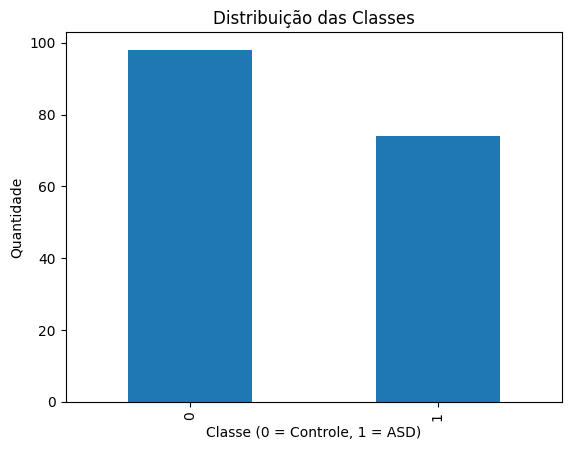

In [ ]:
#  Distribuição das classes
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.title("Distribuição das Classes")
plt.xlabel("Classe (0 = Controle, 1 = ASD)")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
#verificar dados faltantes
print(df.isnull().sum())

i                          0
Unnamed: 0                 0
SUB_ID                     0
X                          0
subject                    0
                        ... 
qc_anat_notes_rater_3    172
qc_func_rater_3            0
qc_func_notes_rater_3    172
SUB_IN_SMP                 0
label                      0
Length: 107, dtype: int64


In [ ]:
# Aumentar o número de ROIs para maior resolução
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200)

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.
nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

In [ ]:
# =========================================
#  6. EXTRAIR SINAIS DO CÉREBRO
# =========================================
import time

inicio = time.time()

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,   # usa o atlas como referência
    standardize=True         # normaliza os sinais
)

time_series = []

# percorre cada exame fMRI
for func_file in abide.func_preproc:
    ts = masker.fit_transform(func_file)  # extrai sinais por região
    time_series.append(ts)                # guarda resultado

fim = time.time()

print("Tempo:", (fim-inicio)/60, "minutos")

/tmp/ipykernel_6828/1424598632.py:17: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(func_file)  # extrai sinais por região
/tmp/ipykernel_6828/1424598632.py:17: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(func_file)  # extrai sinais por região
/tmp/ipykernel_6828/1424598632.py:17: FutureWarning: The 'zscore' strategy incorre

Tempo: 31.10653587579727 minutos


In [ ]:
# =========================================
#  7. CALCULAR CONECTIVIDADE FUNCIONAL
# =========================================
connectivity = ConnectivityMeasure(kind='correlation')

conn_matrices = connectivity.fit_transform(time_series)

/tmp/ipykernel_6828/3282997077.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  conn_matrices = connectivity.fit_transform(time_series)
/tmp/ipykernel_6828/3282997077.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this

In [ ]:
# =========================================
#  8. TRANSFORMAR MATRIZ EM VETOR (ML)
# =========================================
def flatten_matrix(mat):
    return mat[np.triu_indices_from(mat, k=1)]  # pega metade da matriz

# cria matriz de features (X)
X = np.array([flatten_matrix(m) for m in conn_matrices])

# cria vetor de rótulos (y)
y = df['label'].values


# Conferir shapes
print("Shape X:", X.shape)
print("Shape y:", y.shape)

#Estatísticas
print("Média:", X.mean())
print("Desvio padrão:", X.std())

Shape X: (172, 19900)
Shape y: (172,)
Média: 0.20919251320078053
Desvio padrão: 0.22238338733244242


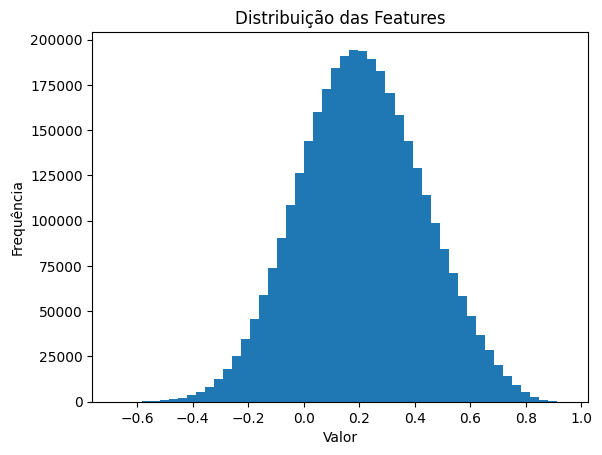

In [ ]:
#Histograma (opcional, mas ótimo)
plt.figure()
plt.hist(X.flatten(), bins=50)

plt.title("Distribuição das Features")
plt.xlabel("Valor")
plt.ylabel("Frequência")

plt.show()

In [ ]:
# =========================================
# 9. VALIDAÇÃO CRUZADA (ANTES DO SPLIT)
# =========================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', StandardScaler()),   # normaliza os dados
    ('pca', PCA(n_components=30)),  # reduz dimensionalidade
    ('svm', SVC(C=1, kernel='rbf')) # modelo
])

scores = cross_val_score(pipe, X, y, cv=5)

print("Acurácia média (CV):", scores.mean())

Acurácia média (CV): 0.627563025210084


In [ ]:
# =========================================
# 10. DIVIDIR DADOS (TREINO / TESTE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% teste
    random_state=42,     # reprodutibilidade
    stratify=y           # mantém proporção das classes
)

In [ ]:
# =========================================
#  11. PIPELINE COMPLETO (SCALER + PCA + SVM)
# =========================================
pipe = Pipeline([
    ('scaler', StandardScaler()),  # normaliza os dados
    ('pca', PCA()),                # reduz dimensionalidade
    ('svm', SVC())                 # modelo de classificação
])

In [ ]:
# =========================================
# 12. GRIDSEARCH (OTIMIZAÇÃO)
# =========================================
param_grid = {
    'pca__n_components': [30, 50, 80, 100],   # quantas features manter
    'svm__C': [0.001, 0.01, 0.1, 1, 10],               # regularização
    'svm__kernel': ['linear', 'rbf'],     # tipo de SVM
    'svm__gamma': ['scale', 'auto'],
    'svm__class_weight': ['balanced']     # balanceamento das classes
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,             # validação cruzada interna
    n_jobs=-1         # usa todos os núcleos disponíveis
)

# treina todos os modelos
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'pca__n_components': 80, 'svm__C': 0.01, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


In [ ]:
# =========================================
# 13. USAR MELHOR MODELO
# =========================================
best_model = grid.best_estimator_

In [ ]:
# =========================================
#  14. FAZER PREVISÕES
# =========================================
y_pred = best_model.predict(X_test)

In [ ]:
# =========================================
# 15. AVALIAÇÃO DO MODELO
# =========================================
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Acurácia: 0.6285714285714286
              precision    recall  f1-score   support

           0       0.65      0.75      0.70        20
           1       0.58      0.47      0.52        15

    accuracy                           0.63        35
   macro avg       0.62      0.61      0.61        35
weighted avg       0.62      0.63      0.62        35



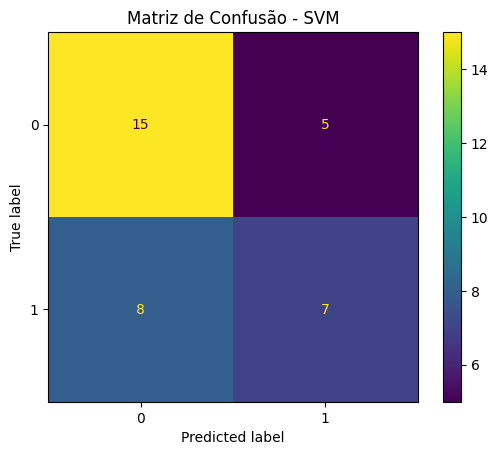

In [ ]:
#MATRIZ CONFUSÃO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de Confusão - SVM")
plt.show()

In [ ]:
# =========================================
#  16. AUC (MÉTRICA AVANÇADA)
# =========================================
y_prob = best_model.decision_function(X_test)

print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.6633333333333333


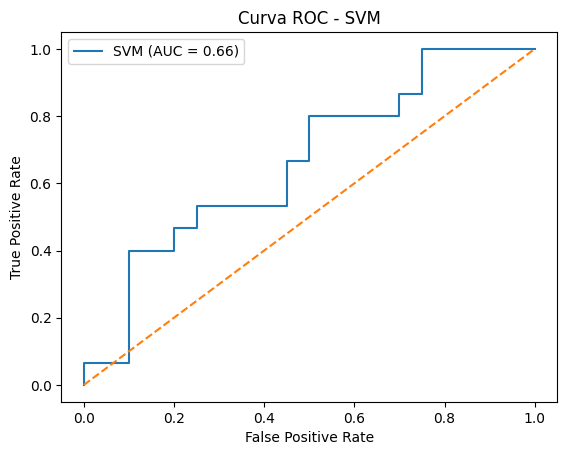

In [ ]:
# CURVA ROC (SVM)
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM")
plt.legend()

plt.show()

In [ ]:
# =========================================
#  17. RANDOM FOREST (COMPARAÇÃO)
# =========================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Acurácia RF:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Acurácia RF: 0.7428571428571429
              precision    recall  f1-score   support

           0       0.72      0.90      0.80        20
           1       0.80      0.53      0.64        15

    accuracy                           0.74        35
   macro avg       0.76      0.72      0.72        35
weighted avg       0.75      0.74      0.73        35



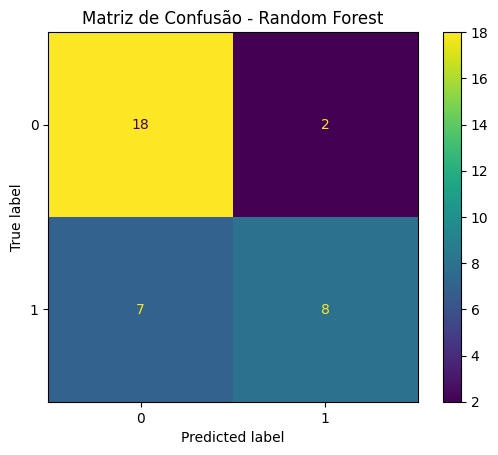

In [ ]:
#MATRIZ DE CONFUSÃO (RF)
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title("Matriz de Confusão - Random Forest")
plt.show()

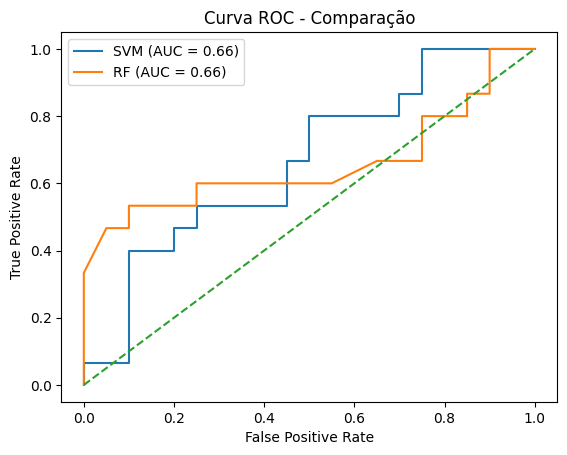

AUC RF: 0.6566666666666665


In [ ]:
#ROC COMPARANDO SVM vs RF

# =========================================
#  CURVA ROC (COMPARAÇÃO)
# =========================================

# Probabilidade RF
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()

plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {roc_auc_rf:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparação")
plt.legend()

plt.show()
print("AUC RF:", roc_auc_rf)

In [ ]:
# =========================================
# 18. INTELIGÊNCIA ARTIFICIAL EXPLICÁVEL (XAI) - DINÂMICO
# Mapeamento de Regiões Cerebrais Relevantes
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Extrair as importâncias calculadas pelo Random Forest
importances = rf.feature_importances_

# 2. Obter os nomes das regiões e o número de ROIs DINAMICAMENTE do atlas carregado
roi_names = [label.decode('utf-8') if isinstance(label, bytes) else str(label) for label in atlas.labels]
n_rois = len(roi_names)

# 3. Obter os índices originais da matriz de conectividade para este número real de ROIs
row_idx, col_idx = np.triu_indices(n_rois, k=1)
num_connections = len(row_idx)

print(f"✔ [LOG] Número de ROIs detectadas no atlas: {n_rois}")
print(f"✔ [LOG] Número de conexões cerebrais esperadas: {num_connections}")
print(f"✔ [LOG] Número total de features encontradas no Random Forest: {len(importances)}")

# 4. Associar cada valor de importância ao seu par de regiões (apenas para as conexões cerebrais)
connections_data = []

# O min() garante que o loop só vai até o limite real das conexões anatômicas
for i in range(min(len(importances), num_connections)):
    reg1 = roi_names[row_idx[i]]
    reg2 = roi_names[col_idx[i]]
    connections_data.append({
        'Regiao_1': reg1,
        'Regiao_2': reg2,
        'Importancia': importances[i]
    })

# Criar DataFrame das conexões e ordenar pelas mais importantes
df_connections = pd.DataFrame(connections_data)
df_connections = df_connections.sort_values(by='Importancia', ascending=False)

print("\n--- TOP 10 CONEXÕES MAIS IMPORTANTES PARA O MODELO ---")
print(df_connections.head(10))
print("\n" + "="*50 + "\n")

# 5. Calcular a importância ACUMULADA por região isolada
region_importances = {}
for roi in roi_names:
    total_imp = df_connections[(df_connections['Regiao_1'] == roi) | (df_connections['Regiao_2'] == roi)]['Importancia'].sum()
    region_importances[roi] = total_imp

# Criar DataFrame das regiões isoladas
df_regions = pd.DataFrame(list(region_importances.items()), columns=['Regiao', 'Importancia_Acumulada'])
df_regions = df_regions.sort_values(by='Importancia_Acumulada', ascending=False)

print("--- TOP 10 REGIÕES CEREBRAIS MAIS RELEVANTES GERAL ---")
print(df_regions.head(10))

# 6. Se houverem variáveis fenotípicas extras no final, mostra a importância delas isoladamente
if len(importances) > num_connections:
    print("\n" + "="*50 + "\n")
    print("--- IMPORTÂNCIA DE CARACTERÍSTICAS EXTRA (FENOTÍPICAS) ---")
    extra_features = importances[num_connections:]
    for idx, imp in enumerate(extra_features):
        print(f"Variável Extra {idx+1}: Importância = {imp:.6f}")

✔ [LOG] Número de ROIs detectadas no atlas: 201
✔ [LOG] Número de conexões cerebrais esperadas: 20100
✔ [LOG] Número total de features encontradas no Random Forest: 19900

--- TOP 10 CONEXÕES MAIS IMPORTANTES PARA O MODELO ---
                             Regiao_1                               Regiao_2  \
10676         7Networks_LH_Cont_Par_3            7Networks_LH_Default_PFC_11   
11605        7Networks_LH_Cont_PFCl_5             7Networks_LH_Default_PFC_9   
3901            7Networks_LH_SomMot_6                    7Networks_RH_Vis_12   
9483   7Networks_LH_SalVentAttn_Med_3               7Networks_RH_Cont_PFCv_1   
14734  7Networks_LH_Default_pCunPCC_1        7Networks_RH_Default_PFCdPFCm_1   
4648           7Networks_LH_SomMot_10  7Networks_RH_SalVentAttn_TempOccPar_2   
1391               7Networks_LH_Vis_7                  7Networks_LH_SomMot_6   
2761              7Networks_LH_Vis_14               7Networks_LH_Cont_PFCl_2   
9565        7Networks_LH_Limbic_OFC_1                

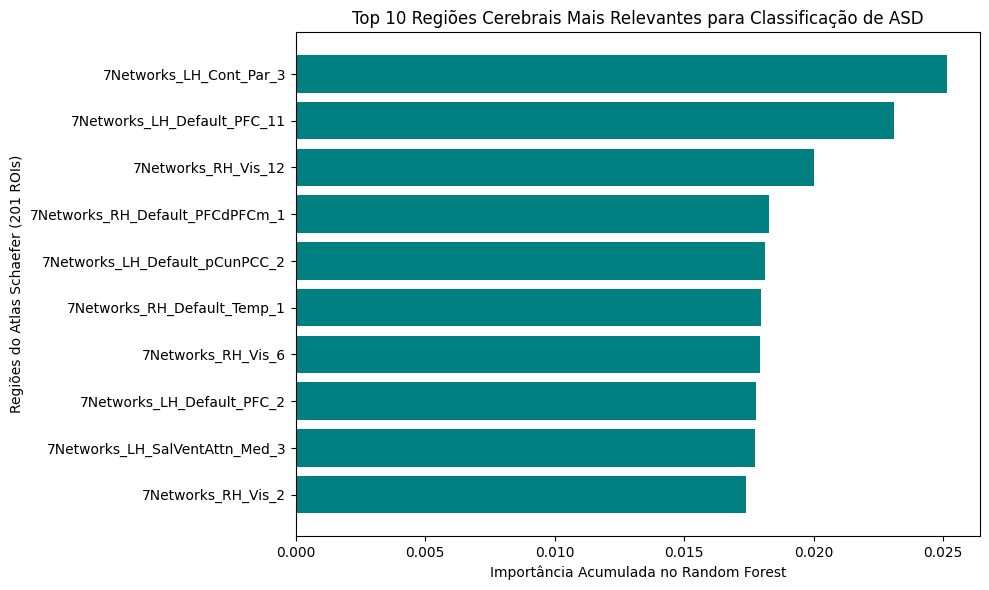

In [ ]:
# =========================================
# 19. GERAR GRÁFICO PARA O TEXTO DO TCC
# =========================================
plt.figure(figsize=(10, 6))
top_10_regions = df_regions.head(10)

plt.barh(top_10_regions['Regiao'][::-1], top_10_regions['Importancia_Acumulada'][::-1], color='teal')
plt.xlabel('Importância Acumulada no Random Forest')
plt.ylabel(f'Regiões do Atlas Schaefer ({n_rois} ROIs)')
plt.title('Top 10 Regiões Cerebrais Mais Relevantes para Classificação de ASD')
plt.tight_layout()
plt.show()

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
!lscpu | head -20
!free -h
!nvidia-smi

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  2
On-line CPU(s) list:                     0,1
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
CPU family:                              6
Model:                                   79
Thread(s) per core:                      2
Core(s) per socket:                      1
Socket(s):                               1
Stepping:                                0
BogoMIPS:                                4400.42
Flags:                                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq 

In [ ]:
import platform

print(platform.system())
print(platform.platform())

Linux
Linux-6.6.122+-x86_64-with-glibc2.35


In [ ]:
import time

inicio = time.time()

# código

fim = time.time()

print("Tempo:", fim - inicio)

Tempo: 0.00020432472229003906
